In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score,precision_score,f1_score,roc_auc_score

In [ ]:
#connect with Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
file_name="/content/drive/MyDrive/GSE15605_series_matrix (1).txt.gz"
file_name1="/content/drive/MyDrive/GSE53462_series_matrix.txt.gz"

In [ ]:
## from .txt file to .csv file code
import gzip

# Read file
with gzip.open(file_name, 'rt') as f:
    lines = f.readlines()

# Find data region between begin and end tags
start, end = 0, 0
for i, line in enumerate(lines):
    if line.startswith("!series_matrix_table_begin"):
        start = i + 1
    elif line.startswith("!series_matrix_table_end"):
        end = i
        break

# Extract only the table part
data_lines = lines[start:end]

# Convert to DataFrame
from io import StringIO
data_str = ''.join(data_lines)
df_expr = pd.read_csv(StringIO(data_str), sep='\t')

# Preview
df_expr.head()

,ID_REF,GSM390208,GSM390209,GSM390210,GSM390211,GSM390212,GSM390213,GSM390214,GSM390215,GSM390216,...,GSM390272,GSM390273,GSM390274,GSM390275,GSM390276,GSM390277,GSM390278,GSM390279,GSM390280,GSM390281
0,1007_s_at,11.020532,10.950778,11.473811,10.822769,10.889048,11.102960,10.530630,10.541802,10.893512,...,10.536372,9.789944,9.387112,10.581330,8.563208,10.054200,9.828538,9.284716,10.724639,10.302563
1,1053_at,8.031035,8.660447,8.150595,8.511551,8.680038,8.456048,7.861925,6.927419,8.906621,...,8.659189,8.657827,9.327206,9.111500,8.561788,8.854245,8.546774,7.166762,9.624508,9.273964
2,117_at,6.973822,7.106163,8.156202,6.437214,6.372524,6.337900,7.736619,5.080306,6.917989,...,8.960423,8.367059,7.786497,8.126415,7.488075,8.493820,7.410054,7.394527,7.087341,8.294484
3,121_at,6.175225,5.464620,6.433634,6.622263,6.456261,6.814377,6.368382,5.920322,7.059717,...,6.433768,6.017126,5.751758,5.796932,6.841726,7.007100,5.966656,5.287752,5.781160,7.677899
4,1294_at,8.308560,8.395153,9.750258,8.246585,7.963901,8.057381,8.520238,7.913927,8.682314,...,8.870373,9.070832,9.549103,8.806603,7.924857,8.303491,7.707022,9.365837,8.369271,7.051232


In [ ]:
## from .txt file to .csv file code
import gzip

# Read file
with gzip.open(file_name1, 'rt') as f:
    lines = f.readlines()

# Find data region between begin and end tags
start, end = 0, 0
for i, line in enumerate(lines):
    if line.startswith("!series_matrix_table_begin"):
        start = i + 1
    elif line.startswith("!series_matrix_table_end"):
        end = i
        break

# Extract only the table part
data_lines = lines[start:end]

# Convert to DataFrame
from io import StringIO
data_str = ''.join(data_lines)
df_expr1 = pd.read_csv(StringIO(data_str), sep='\t')

# Preview
df_expr1.head()

,ID_REF,GSM1294012,GSM1294013,GSM1294014,GSM1294015,GSM1294016,GSM1294017,GSM1294018,GSM1294019,GSM1294020,...,GSM1294028,GSM1294029,GSM1294030,GSM1294031,GSM1294032,GSM1294033,GSM1294034,GSM1294035,GSM1294036,GSM1294037
0,ILMN_1343291,14.205476,14.186829,14.075314,14.019967,14.205476,14.030549,14.186829,14.125661,14.205476,...,14.205476,14.132103,14.158385,14.120496,14.236208,13.924311,13.899739,14.092362,13.960668,14.062185
1,ILMN_1343295,12.451549,12.364625,13.218503,12.298331,13.010652,13.663575,13.842032,13.214198,12.875049,...,12.889979,12.926569,12.926569,13.397086,12.367492,13.151000,13.084277,12.676534,12.814648,13.111005
2,ILMN_1651199,5.690015,5.592982,5.738018,5.662791,5.650318,5.737076,5.536262,5.705039,5.815015,...,5.797392,5.745516,5.557857,5.575901,5.884680,5.628778,5.638544,5.644409,5.721312,5.589908
3,ILMN_1651209,6.015965,6.029157,6.248047,6.329506,6.031347,5.632956,6.062245,6.006916,5.770816,...,5.838043,6.170531,5.894573,6.070159,5.856225,6.037968,6.079140,6.267488,6.002930,6.138057
4,ILMN_1651210,5.624295,5.504329,5.594853,5.780805,5.854735,5.797355,5.862834,5.790549,5.840153,...,5.634124,5.784194,5.731993,5.741699,5.782058,5.972688,5.859338,5.878503,6.009426,5.724924


In [ ]:
df_expr.shape

(44137, 75)

In [ ]:
df_expr1.shape

(47323, 27)

In [ ]:
#read the tables extracted from NCBI after GEO2R analysis of the datasets

df = pd.read_csv("/content/drive/MyDrive/GSE15605.top.table.tsv", sep='\t')

df1 = pd.read_csv("/content/drive/MyDrive/GSE53462.top.table (2).tsv", sep='\t')


In [ ]:
df.head()

,ID,adj.P.Val,P.Value,t,B,logFC,Gene.symbol,Gene.title
0,227230_s_at,4.970000e-18,1.130000e-22,14.021805,40.847077,3.790932,KIAA1211,KIAA1211
1,243585_at,5.350000e-17,2.430000e-21,-13.243837,37.898073,-3.416183,ATP13A5,ATPase 13A5
2,1553946_at,1.540000e-16,1.040000e-20,-12.880274,36.491882,-8.104731,DCD,dermcidin
3,220970_s_at,1.840000e-16,1.670000e-20,-12.765092,36.042725,-5.259375,KRTAP2-3///KRTAP2-4,keratin associated protein 2-3///keratin assoc...
4,1557474_at,2.050000e-16,2.330000e-20,-12.682804,35.720776,-2.945402,LOC284578,uncharacterized LOC284578


In [ ]:
df1.head()

,ID,adj.P.Val,P.Value,t,B,logFC,GI,Gene.symbol,Gene.title
0,ILMN_1812000,1.680000e-15,3.560000e-20,26.119538,33.606974,1.919003,NaN,NaN,NaN
1,ILMN_1699867,1.740000e-13,7.360000e-18,21.073902,29.417229,2.456789,673132012.0,IGF2,insulin like growth factor 2
2,ILMN_3308961,8.130000e-13,5.160000e-17,19.463316,27.791612,2.184442,NaN,NaN,NaN
3,ILMN_3217771,4.510000e-12,3.820000e-16,17.920828,26.074010,1.566259,NaN,NaN,NaN
4,ILMN_3273491,7.950000e-12,8.410000e-16,17.341587,25.384159,1.896856,NaN,NaN,NaN


In [ ]:
# Drop empty or ambiguous gene symbols
df = df[df['Gene.symbol'].notnull()]
df = df[~df['Gene.symbol'].str.contains('///', na=False)]
df['Gene.symbol'] = df['Gene.symbol'].str.strip().str.upper()
df = df[df['Gene.symbol'] != '']

# Remove LOC and pseudogenes if needed
df = df[~df['Gene.symbol'].str.contains('^LOC|P\\d+$', na=False, regex=True)]
# Keep only best probe per gene (e.g., lowest p-value)
df = df.sort_values('adj.P.Val').drop_duplicates('Gene.symbol', keep='first')

In [ ]:
df.isnull().sum()

,0
ID,0
adj.P.Val,0
P.Value,0
t,0
B,0
logFC,0
Gene.symbol,0
Gene.title,0


In [ ]:
# Filter criteria
DEGs = df[(df["adj.P.Val"] < 0.05) & (df["logFC"].abs() > 1)]
DEGs.to_csv("degs.csv", index=False)

In [ ]:
# Drop empty or ambiguous gene symbols
df1 = df1[df1['Gene.symbol'].notnull()]
df1 = df1[~df1['Gene.symbol'].str.contains('///', na=False)]
df1['Gene.symbol'] = df1['Gene.symbol'].str.strip().str.upper()
df1 = df1[df1['Gene.symbol'] != '']
# Remove LOC and pseudogenes if needed
df1 = df1[~df1['Gene.symbol'].str.contains('^LOC|P\\d+$', na=False, regex=True)]
# Keep only best probe per gene (e.g., lowest p-value)
df1 = df1.sort_values('adj.P.Val').drop_duplicates('Gene.symbol', keep='first')

In [ ]:
df1.isnull().sum()

,0
ID,0
adj.P.Val,0
P.Value,0
t,0
B,0
logFC,0
GI,0
Gene.symbol,0
Gene.title,0


In [ ]:
# Filter criteria
DEGs1 = df1[(df1["adj.P.Val"] < 0.05) & (df1["logFC"].abs() > 1)]
DEGs1.to_csv("degs1.csv", index=False)

In [ ]:
DEGs.head()

,ID,adj.P.Val,P.Value,t,B,logFC,Gene.symbol,Gene.title
0,227230_s_at,4.970000e-18,1.130000e-22,14.021805,40.847077,3.790932,KIAA1211,KIAA1211
1,243585_at,5.350000e-17,2.430000e-21,-13.243837,37.898073,-3.416183,ATP13A5,ATPase 13A5
2,1553946_at,1.540000e-16,1.040000e-20,-12.880274,36.491882,-8.104731,DCD,dermcidin
5,205979_at,3.860000e-16,5.250000e-20,-12.483223,34.936275,-5.133770,SCGB2A1,secretoglobin family 2A member 1
6,219932_at,6.030000e-16,9.560000e-20,-12.336702,34.357079,-3.404638,SLC27A6,solute carrier family 27 member 6


In [ ]:
DEGs.shape

(2957, 8)

In [ ]:
DEGs1.head()

,ID,adj.P.Val,P.Value,t,B,logFC,GI,Gene.symbol,Gene.title
1,ILMN_1699867,1.740000e-13,7.360000e-18,21.073902,29.417229,2.456789,673132012.0,IGF2,insulin like growth factor 2
10,ILMN_2180997,1.010000e-10,2.340000e-14,15.072132,22.415032,1.874856,91823780.0,GTF2IRD2B,GTF2I repeat domain containing 2B
12,ILMN_2402499,4.010000e-10,1.100000e-13,14.099281,20.997693,1.263480,345525411.0,MSMO1,methylsterol monooxygenase 1
18,ILMN_2149400,2.270000e-09,9.110000e-13,12.853905,19.039968,1.702691,23510353.0,SPC25,"SPC25, NDC80 kinetochore complex component"
34,ILMN_1686992,1.420000e-08,1.070000e-11,11.507686,16.724260,1.002696,110624782.0,TEDDM1,transmembrane epididymal protein 1


In [ ]:
DEGs1.shape

(475, 9)

In [ ]:
df_deg=DEGs
df_deg1=DEGs1

In [ ]:
df_deg["ID"] = df_deg["ID"].astype(str)
df_expr["ID_REF"] = df_expr["ID_REF"].astype(str)

# Filter df_expr where ID_REF is in df_deg
df_expr_filtered = df_expr[df_expr["ID_REF"].isin(df_deg["ID"])]

/tmp/ipython-input-23094686.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg["ID"] = df_deg["ID"].astype(str)


In [ ]:
df_expr_filtered.head()

,ID_REF,GSM390208,GSM390209,GSM390210,GSM390211,GSM390212,GSM390213,GSM390214,GSM390215,GSM390216,...,GSM390272,GSM390273,GSM390274,GSM390275,GSM390276,GSM390277,GSM390278,GSM390279,GSM390280,GSM390281
2,117_at,6.973822,7.106163,8.156202,6.437214,6.372524,6.337900,7.736619,5.080306,6.917989,...,8.960423,8.367059,7.786497,8.126415,7.488075,8.493820,7.410054,7.394527,7.087341,8.294484
7,1405_i_at,3.943153,5.350128,4.926322,7.421946,5.243261,5.183260,5.981511,5.853094,7.900276,...,8.736859,10.980054,9.540650,8.701574,6.665786,9.473377,5.288100,10.065445,6.364060,5.517725
8,1431_at,5.568921,7.253492,4.773683,5.810471,6.025198,6.348998,6.207570,6.118145,7.054047,...,4.039616,4.078975,4.127997,5.284211,3.721023,4.059567,4.079938,3.779504,3.596029,4.379086
26,1552279_a_at,4.647607,4.755359,4.614630,4.980603,3.768790,5.164930,5.032902,4.553380,5.992561,...,6.164433,6.662540,6.101926,6.034365,5.938345,6.386253,5.909594,6.915436,5.660900,6.545547
50,1552319_a_at,5.877647,6.166227,4.223541,6.640972,5.928663,6.127695,7.886308,3.288236,5.971104,...,3.033042,3.163194,3.044482,3.394861,3.281643,6.147075,4.492198,2.668598,3.224265,2.877963


In [ ]:
df_expr_filtered.shape

(2957, 75)

In [ ]:
df = df_expr_filtered.reset_index(drop=True)
df=df.T
df.head()

,0,1,2,3,4,5,6,7,8,9,...,2947,2948,2949,2950,2951,2952,2953,2954,2955,2956
ID_REF,117_at,1405_i_at,1431_at,1552279_a_at,1552319_a_at,1552330_at,1552394_a_at,1552400_a_at,1552410_at,1552478_a_at,...,40560_at,44702_at,44783_s_at,47550_at,48030_i_at,52164_at,55093_at,57588_at,59375_at,65517_at
GSM390208,6.973822,3.943153,5.568921,4.647607,5.877647,5.043496,2.687525,4.680931,5.61016,6.339912,...,5.83452,5.464702,9.997738,8.444279,10.007733,8.791158,7.671255,8.038263,7.576338,7.15819
GSM390209,7.106163,5.350128,7.253492,4.755359,6.166227,5.345421,3.248132,4.962281,5.928166,5.164221,...,5.022484,5.051399,9.217339,7.895753,10.778725,9.146911,7.837441,8.249271,7.766321,7.855599
GSM390210,8.156202,4.926322,4.773683,4.61463,4.223541,2.931496,3.052278,4.711999,7.268705,3.851475,...,5.342149,8.437061,8.14939,8.448104,10.418655,9.014437,7.346803,7.608068,8.861929,6.560826
GSM390211,6.437214,7.421946,5.810471,4.980603,6.640972,6.45375,3.300071,6.68125,4.85542,5.634361,...,6.496815,5.702268,10.306271,8.15408,10.037243,9.838157,7.327734,7.985544,6.949881,7.589242


In [ ]:
# Replace columns with the values from the ID_REF row
df.columns = df.iloc[0]  # Set first row as header
df = df[1:]              # Drop the first row


In [ ]:
df.head()

ID_REF,117_at,1405_i_at,1431_at,1552279_a_at,1552319_a_at,1552330_at,1552394_a_at,1552400_a_at,1552410_at,1552478_a_at,...,40560_at,44702_at,44783_s_at,47550_at,48030_i_at,52164_at,55093_at,57588_at,59375_at,65517_at
GSM390208,6.973822,3.943153,5.568921,4.647607,5.877647,5.043496,2.687525,4.680931,5.61016,6.339912,...,5.83452,5.464702,9.997738,8.444279,10.007733,8.791158,7.671255,8.038263,7.576338,7.15819
GSM390209,7.106163,5.350128,7.253492,4.755359,6.166227,5.345421,3.248132,4.962281,5.928166,5.164221,...,5.022484,5.051399,9.217339,7.895753,10.778725,9.146911,7.837441,8.249271,7.766321,7.855599
GSM390210,8.156202,4.926322,4.773683,4.61463,4.223541,2.931496,3.052278,4.711999,7.268705,3.851475,...,5.342149,8.437061,8.14939,8.448104,10.418655,9.014437,7.346803,7.608068,8.861929,6.560826
GSM390211,6.437214,7.421946,5.810471,4.980603,6.640972,6.45375,3.300071,6.68125,4.85542,5.634361,...,6.496815,5.702268,10.306271,8.15408,10.037243,9.838157,7.327734,7.985544,6.949881,7.589242
GSM390212,6.372524,5.243261,6.025198,3.76879,5.928663,6.214907,3.056334,6.419923,6.288116,6.050149,...,5.927864,5.172957,10.055467,8.054526,9.165141,9.39236,6.53128,8.585538,7.767462,7.013253


In [ ]:
import pandas as pd

# Assume df is already loaded and rows are samples

df['target'] = [0] * 16+ [1] * 58

# Optional: Check distribution
print(df['target'].value_counts())

print(df.head())


target
1    58
0    16
Name: count, dtype: int64
ID_REF       117_at 1405_i_at   1431_at 1552279_a_at 1552319_a_at 1552330_at  \
GSM390208  6.973822  3.943153  5.568921     4.647607     5.877647   5.043496   
GSM390209  7.106163  5.350128  7.253492     4.755359     6.166227   5.345421   
GSM390210  8.156202  4.926322  4.773683      4.61463     4.223541   2.931496   
GSM390211  6.437214  7.421946  5.810471     4.980603     6.640972    6.45375   
GSM390212  6.372524  5.243261  6.025198      3.76879     5.928663   6.214907   

ID_REF    1552394_a_at 1552400_a_at 1552410_at 1552478_a_at  ...  44702_at  \
GSM390208     2.687525     4.680931    5.61016     6.339912  ...  5.464702   
GSM390209     3.248132     4.962281   5.928166     5.164221  ...  5.051399   
GSM390210     3.052278     4.711999   7.268705     3.851475  ...  8.437061   
GSM390211     3.300071      6.68125    4.85542     5.634361  ...  5.702268   
GSM390212     3.056334     6.419923   6.288116     6.050149  ...  5.172957   

I

In [ ]:
features = np.array(df.columns[:-1])
target = 'target'

X = df[features]
y = df[target]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.utils import shuffle
from imblearn.pipeline import Pipeline
import lightgbm as lgb

Cross-Validation Results (5-Fold):
Accuracy  : 0.9867 ± 0.0267
Precision : 0.9833 ± 0.0333
Recall    : 1.0000 ± 0.0000
F1-Score  : 0.9913 ± 0.0174

Model Performance on Test Set:
Accuracy  : 0.9333
Precision : 0.9231
Recall    : 1.0000
F1-Score  : 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.92      1.00      0.96        12

    accuracy                           0.93        15
   macro avg       0.96      0.83      0.88        15
weighted avg       0.94      0.93      0.93        15



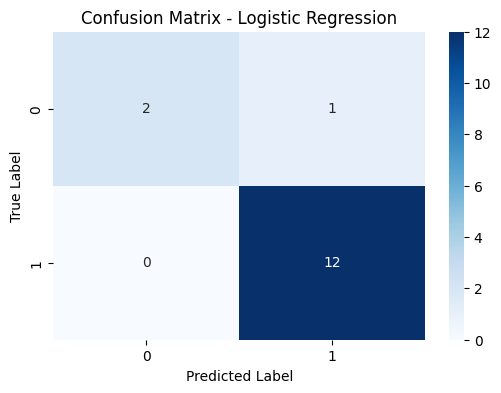

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- Cross-Fold Validation (added) ---
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
cv_precision = cross_val_score(model, X, y, cv=kfold, scoring='precision')
cv_recall = cross_val_score(model, X, y, cv=kfold, scoring='recall')
cv_f1 = cross_val_score(model, X, y, cv=kfold, scoring='f1')

print("Cross-Validation Results (5-Fold):")
print(f"Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")


# --- Your Original Code (unchanged) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# --- Performance Metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("\nModel Performance on Test Set:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")

filename = "Confusion_Matrix_LogisticRegression.png"
plt.savefig(f"/content/sample_data/{filename}", dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
# SHAP explanation for linear models
explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Compute mean absolute SHAP value per gene
shap_mean = np.abs(shap_values).mean(axis=0)

# Store all genes
importance_df_logiR = pd.DataFrame({
    "ID_REF": X.columns,
    "SHAP_Importance": shap_mean
}).sort_values("SHAP_Importance", ascending=False)

# Save full SHAP result
importance_df_logiR.to_csv("All_SHAP_LogisticRegression.csv", index=False)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
importance_df_logiR.head(400)

,ID_REF,SHAP_Importance
55,1553946_at,0.15568
812,206509_at,0.121041
2717,237732_at,0.089515
1437,217059_at,0.087762
799,206378_at,0.087013
...,...,...
699,205653_at,0.012686
1275,213486_at,0.012621
2724,238018_at,0.01261
2201,228260_at,0.012595


In [ ]:
df_deg1["ID"] = df_deg1["ID"].astype(str)
df_expr1["ID_REF"] = df_expr1["ID_REF"].astype(str)

# Filter df_expr where ID_REF is in df_deg
df_expr_filtered1 = df_expr1[df_expr1["ID_REF"].isin(df_deg1["ID"])]

/tmp/ipython-input-543091145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg1["ID"] = df_deg1["ID"].astype(str)


In [ ]:
df_expr_filtered1.head()

,ID_REF,GSM1294012,GSM1294013,GSM1294014,GSM1294015,GSM1294016,GSM1294017,GSM1294018,GSM1294019,GSM1294020,...,GSM1294028,GSM1294029,GSM1294030,GSM1294031,GSM1294032,GSM1294033,GSM1294034,GSM1294035,GSM1294036,GSM1294037
119,ILMN_1651617,7.087857,7.444832,7.733395,8.212188,7.834467,7.162279,7.632351,7.013335,7.907242,...,7.245463,7.795151,7.154819,7.775897,7.841669,6.200521,6.101128,6.109469,6.043471,6.187714
452,ILMN_1653028,9.179699,10.468674,11.376265,10.883257,10.487680,11.173488,10.560903,8.926315,11.508711,...,10.278717,10.638900,10.986766,11.641887,10.558934,9.271955,9.758307,9.455011,8.597502,9.514813
472,ILMN_1653125,5.893259,6.046450,5.855467,6.128254,6.064220,5.637226,6.128254,6.011528,5.943481,...,6.065791,6.289712,5.839115,6.014596,6.050872,7.065707,7.270343,7.148172,6.601543,7.210618
550,ILMN_1653447,8.047252,10.155585,9.848004,6.437025,9.593659,6.199494,7.616846,7.596073,8.097653,...,9.969017,9.003504,9.117660,9.550787,8.801614,10.337996,10.989172,10.258885,11.923432,10.714615
684,ILMN_1654065,6.290492,6.071363,5.902546,6.032963,5.991837,5.861767,5.683910,6.464208,5.790656,...,6.252003,6.081230,6.498563,5.862590,5.951438,6.759853,7.077339,7.624781,7.250497,7.394191


In [ ]:
df1 = df_expr_filtered1.reset_index(drop=True)
df1=df1.T
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,465,466,467,468,469,470,471,472,473,474
ID_REF,ILMN_1651617,ILMN_1653028,ILMN_1653125,ILMN_1653447,ILMN_1654065,ILMN_1654287,ILMN_1654411,ILMN_1654571,ILMN_1655637,ILMN_1656706,...,ILMN_3243466,ILMN_3243593,ILMN_3243749,ILMN_3245297,ILMN_3245418,ILMN_3247560,ILMN_3248515,ILMN_3287874,ILMN_3307483,ILMN_3307901
GSM1294012,7.087857,9.179699,5.893259,8.047252,6.290492,6.804517,7.418447,6.02088,7.121085,9.0705,...,6.329506,11.433327,6.717094,6.628705,6.579401,8.134215,7.728546,8.120594,7.215066,6.737059
GSM1294013,7.444832,10.468674,6.04645,10.155585,6.071363,7.00423,6.005946,6.37733,5.957968,10.797154,...,7.358674,11.460397,7.211068,8.006687,6.339148,8.413097,9.62961,7.502051,7.484103,6.902421
GSM1294014,7.733395,11.376265,5.855467,9.848004,5.902546,6.635752,6.983515,6.436417,5.760992,11.626679,...,7.49749,12.537391,6.776189,7.18802,6.468742,8.117546,9.951633,9.092501,6.86786,6.82127
GSM1294015,8.212188,10.883257,6.128254,6.437025,6.032963,6.064708,5.712885,5.572947,6.001608,6.005073,...,5.524869,11.696233,7.371311,6.670326,6.087817,6.450029,6.052901,7.298014,6.65075,5.778379


In [ ]:
# Replace columns with the values from the ID_REF row
df1.columns = df1.iloc[0]  # Set first row as header
df1= df1[1:]              # Drop the first row


In [ ]:
df1.head()

ID_REF,ILMN_1651617,ILMN_1653028,ILMN_1653125,ILMN_1653447,ILMN_1654065,ILMN_1654287,ILMN_1654411,ILMN_1654571,ILMN_1655637,ILMN_1656706,...,ILMN_3243466,ILMN_3243593,ILMN_3243749,ILMN_3245297,ILMN_3245418,ILMN_3247560,ILMN_3248515,ILMN_3287874,ILMN_3307483,ILMN_3307901
GSM1294012,7.087857,9.179699,5.893259,8.047252,6.290492,6.804517,7.418447,6.02088,7.121085,9.0705,...,6.329506,11.433327,6.717094,6.628705,6.579401,8.134215,7.728546,8.120594,7.215066,6.737059
GSM1294013,7.444832,10.468674,6.04645,10.155585,6.071363,7.00423,6.005946,6.37733,5.957968,10.797154,...,7.358674,11.460397,7.211068,8.006687,6.339148,8.413097,9.62961,7.502051,7.484103,6.902421
GSM1294014,7.733395,11.376265,5.855467,9.848004,5.902546,6.635752,6.983515,6.436417,5.760992,11.626679,...,7.49749,12.537391,6.776189,7.18802,6.468742,8.117546,9.951633,9.092501,6.86786,6.82127
GSM1294015,8.212188,10.883257,6.128254,6.437025,6.032963,6.064708,5.712885,5.572947,6.001608,6.005073,...,5.524869,11.696233,7.371311,6.670326,6.087817,6.450029,6.052901,7.298014,6.65075,5.778379
GSM1294016,7.834467,10.48768,6.06422,9.593659,5.991837,6.590228,6.564794,6.16407,6.31077,11.769877,...,7.470339,12.381946,7.305448,7.520892,6.695681,8.305081,10.522253,8.552585,6.782115,6.672588


In [ ]:
import pandas as pd

# Assume df is already loaded and rows are samples

df1['target'] = [1] * 21+ [0] * 5

# Optional: Check distribution
print(df1['target'].value_counts())

print(df1.head())


target
1    21
0     5
Name: count, dtype: int64
ID_REF     ILMN_1651617 ILMN_1653028 ILMN_1653125 ILMN_1653447 ILMN_1654065  \
GSM1294012     7.087857     9.179699     5.893259     8.047252     6.290492   
GSM1294013     7.444832    10.468674      6.04645    10.155585     6.071363   
GSM1294014     7.733395    11.376265     5.855467     9.848004     5.902546   
GSM1294015     8.212188    10.883257     6.128254     6.437025     6.032963   
GSM1294016     7.834467     10.48768      6.06422     9.593659     5.991837   

ID_REF     ILMN_1654287 ILMN_1654411 ILMN_1654571 ILMN_1655637 ILMN_1656706  \
GSM1294012     6.804517     7.418447      6.02088     7.121085       9.0705   
GSM1294013      7.00423     6.005946      6.37733     5.957968    10.797154   
GSM1294014     6.635752     6.983515     6.436417     5.760992    11.626679   
GSM1294015     6.064708     5.712885     5.572947     6.001608     6.005073   
GSM1294016     6.590228     6.564794      6.16407      6.31077    11.769877   

I

In [ ]:
features = np.array(df1.columns[:-1])
target = 'target'

X = df1[features]
y = df1[target]

Model Performance Metrics:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



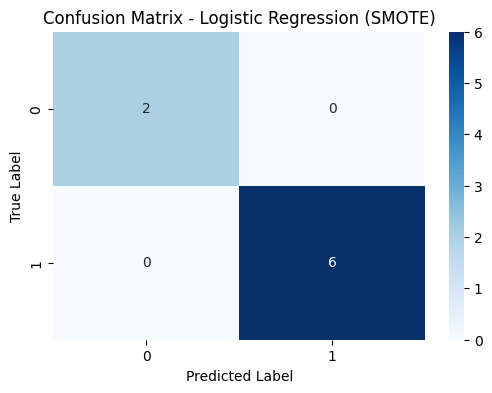

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# --- Train model ---
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

# --- Predict on original test set ---
y_pred = model.predict(X_test)

# --- Performance Metrics ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')   # change to 'weighted' if multiclass
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("Model Performance Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")

# Save confusion matrix
filename = "Confusion_Matrix_LogisticRegression_SMOTE.png"
plt.savefig(f"/content/sample_data/{filename}", dpi=600, bbox_inches='tight')

plt.show()

In [ ]:
# SHAP explanation for linear models
explainer = shap.LinearExplainer(model, X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

# Compute mean absolute SHAP value per gene
shap_mean = np.abs(shap_values).mean(axis=0)

# Store all genes
importance_df1_logiR = pd.DataFrame({
    "ID_REF": X.columns,
    "SHAP_Importance": shap_mean
}).sort_values("SHAP_Importance", ascending=False)

# Save full SHAP result
importance_df1_logiR.to_csv("All_SHAP_LogisticRegression1.csv", index=False)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
importance_df1_logiR.head(400)

,ID_REF,SHAP_Importance
31,ILMN_1669299,0.115989
112,ILMN_1698772,0.077724
377,ILMN_2113606,0.076277
233,ILMN_1754576,0.074981
428,ILMN_2353936,0.072667
...,...,...
423,ILMN_2342638,0.003798
443,ILMN_2394287,0.003782
60,ILMN_1677038,0.003715
109,ILMN_1697561,0.003584


In [ ]:
#read the tables of 200 gene id of the datasets

data = importance_df_logiR.head(400)

data1 = importance_df1_logiR.head(400)


In [ ]:
DEGs["ID"] = DEGs["ID"].astype(str)
data["ID_REF"] = data["ID_REF"].astype(str)

# Filter df_expr where ID_REF is in df_deg
filtered_gene_symbol = DEGs[DEGs["ID"].isin(data["ID_REF"])]

/tmp/ipython-input-1096869819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["ID_REF"] = data["ID_REF"].astype(str)


In [ ]:
filtered_gene_symbol.head()

,ID,adj.P.Val,P.Value,t,B,logFC,Gene.symbol,Gene.title
0,227230_s_at,4.970000e-18,1.130000e-22,14.021805,40.847077,3.790932,KIAA1211,KIAA1211
1,243585_at,5.350000e-17,2.430000e-21,-13.243837,37.898073,-3.416183,ATP13A5,ATPase 13A5
2,1553946_at,1.540000e-16,1.040000e-20,-12.880274,36.491882,-8.104731,DCD,dermcidin
5,205979_at,3.860000e-16,5.250000e-20,-12.483223,34.936275,-5.133770,SCGB2A1,secretoglobin family 2A member 1
6,219932_at,6.030000e-16,9.560000e-20,-12.336702,34.357079,-3.404638,SLC27A6,solute carrier family 27 member 6


In [ ]:
filtered_gene_symbol.shape

(400, 8)

In [ ]:
filtered_gene_symbol.to_csv("gene_symbol400.csv", index=False)

In [ ]:
DEGs1["ID"] = DEGs1["ID"].astype(str)
data1["ID_REF"] = data1["ID_REF"].astype(str)

# Filter df_expr where ID_REF is in df_deg
filtered_gene_symbol1 = DEGs1[DEGs1["ID"].isin(data1["ID_REF"])]

/tmp/ipython-input-3650807898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1["ID_REF"] = data1["ID_REF"].astype(str)


In [ ]:
filtered_gene_symbol1.head()

,ID,adj.P.Val,P.Value,t,B,logFC,GI,Gene.symbol,Gene.title
1,ILMN_1699867,1.740000e-13,7.360000e-18,21.073902,29.417229,2.456789,673132012.0,IGF2,insulin like growth factor 2
10,ILMN_2180997,1.010000e-10,2.340000e-14,15.072132,22.415032,1.874856,91823780.0,GTF2IRD2B,GTF2I repeat domain containing 2B
12,ILMN_2402499,4.010000e-10,1.100000e-13,14.099281,20.997693,1.263480,345525411.0,MSMO1,methylsterol monooxygenase 1
18,ILMN_2149400,2.270000e-09,9.110000e-13,12.853905,19.039968,1.702691,23510353.0,SPC25,"SPC25, NDC80 kinetochore complex component"
34,ILMN_1686992,1.420000e-08,1.070000e-11,11.507686,16.724260,1.002696,110624782.0,TEDDM1,transmembrane epididymal protein 1


In [ ]:
filtered_gene_symbol1.shape

(400, 9)

In [ ]:
filtered_gene_symbol1.to_csv("gene_symbol1_400.csv", index=False)